In [1]:
#TASEP with Gillespie
using ExponentialQueues    # code by Prof. A. Braunstein
using Graphs
using Graphs.SimpleGraphs
using LaTeXStrings
using LinearAlgebra
using Plots
using Printf
using ProgressMeter
using Random
using StatsBase
using SparseArrays
using OffsetArrays

In [2]:
function show_state(s)
    heatmap(reshape(s,1,L),c=cgrad([:blue, :red]),clim=(0,1))
end

function trajectory(s, t, alpha, beta, T; stats = (x...) -> nothing)
    L = length(s)
    T += t
    R = ExponentialQueue(L+1)
    prog = ProgressUnknown("Iterations:")
    rates = [alpha; ones(L-1); beta]
    for i in 1:L-1
        if s[i] == 1 && s[i+1] == 0
            R[i+1] = rates[i+1]
        end
    end
    if s[1] == 0
        R[1] = rates[1]
    end
    if s[L] == 1
        R[L+1] = rates[L+1]
    end 
    stats(t,0,s)

    while !isempty(R)
        i, Δt = pop!(R)
        t += Δt                                                 
        t > T && break                                         
        
        ProgressMeter.next!(prog,showvalues = [(:t,t)]);

        if i == 1
            s[1] = 1
            if s[2] == 0
                R[2] = rates[2]
            end
        elseif i == L+1
            s[L] = 0
            if s[L-1] == 1
                R[L] = rates[L]
            end
        else
            s[i] = 1
            s[i-1] = 0
            if i==2 || s[i-2] == 1
                R[i-1] = rates[i-1]
            end
            if i == L || s[i+1] == 0
                R[i+1] = rates[i+1]
            end
        end
        stats(t, i, s)
    end
    t, s
end

trajectory (generic function with 1 method)

In [3]:
function ContinuousTrajectory(L)

    N = []
    Events = []
    n = BitVector(fill(0, L))
   
    times = Float64[]
    
    function stats(t, i, s)
        push!(times, t)
        n = copy(s)
        if t == 0.0
            n = copy(s)
        elseif i == 0
            n = copy(s)
        elseif i == 1
            
            n[i] = 1
        elseif i == L+1
            
            n[i-1] = 0
        else
            
            n[i] = 1
            n[i-1] = 0 
        end
        push!(N, n)
        push!(Events, i)
    end
end

ContinuousTrajectory (generic function with 1 method)

In [4]:
L = 200;
α = 0.1;
β = 0.2;
weights = [fill(α, L÷2); fill(1-β, L÷2)]
s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
s = [s1; s2]
ProgressMeter.ijulia_behavior(:clear)

t_list=[]
t=0.0;
races = 150
M = []

Any[]

In [5]:
for j in 1:races
    s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
    s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
    s = [s1; s2]
    T = 2000
    stats = ContinuousTrajectory(L)
    t, s = trajectory(s, t, α, β, T; stats = stats)
    #println(t)
    show_state(s)
    N = hcat(stats.N...)
    t_list = stats.times
    iter = length(t_list)
    #println(iter)
    events = stats.Events
    push!(M, N)
end

Iterations: 30520    Time: 0:00:00

In [6]:
p = [size(M[i])[2] for i in 1:races]
p = minimum(p)
D = zeros(Bool, L, p, races)
for i in 1:races
    D[:,:,i]=M[i][:, 1:p]
end
#D = reshape(D, L, p, races)
D = (sum(D, dims=3) ./ races)[:,:,1]

200×31928 Matrix{Float64}:
 0.133333   0.126667   0.14       …  0.1        0.0933333  0.08
 0.146667   0.146667   0.14          0.113333   0.12       0.126667
 0.0933333  0.106667   0.113333      0.12       0.113333   0.12
 0.133333   0.133333   0.12          0.1        0.106667   0.106667
 0.106667   0.106667   0.12          0.106667   0.1        0.0866667
 0.0866667  0.0733333  0.0666667  …  0.113333   0.12       0.133333
 0.153333   0.153333   0.16          0.0933333  0.0866667  0.0866667
 0.126667   0.14       0.133333      0.106667   0.106667   0.106667
 0.0933333  0.08       0.08          0.06       0.0666667  0.0666667
 0.08       0.0933333  0.0933333     0.1        0.1        0.1
 ⋮                                ⋱  ⋮                     
 0.753333   0.753333   0.766667      0.08       0.0866667  0.08
 0.78       0.78       0.78          0.14       0.133333   0.14
 0.806667   0.813333   0.806667      0.1        0.106667   0.1
 0.82       0.82       0.8           0.14       0.12

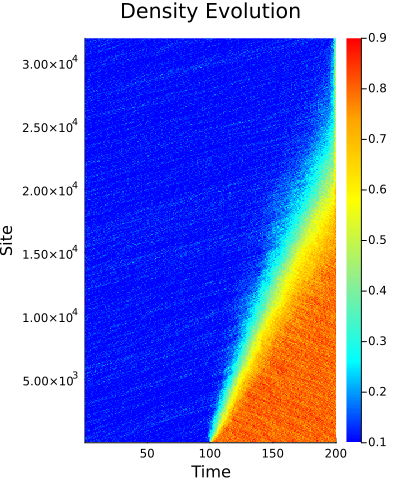

In [7]:
heatmap(D', c=cgrad([:blue, :cyan, :lightgreen, :yellow, :orange, :red]), clim=(0.1,0.9), xlabel="Time", ylabel="Site", title="Density Evolution", size=(400,500))

In [8]:
    s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
    s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
    s = [s1; s2]
    T = 2000
    stats = ContinuousTrajectory(L)
    t, s = trajectory(s, t, α, β, T; stats = stats)
    #println(t)
    show_state(s)
    N = hcat(stats.N...)
    t_list = stats.times
    iter = length(t_list)
    #println(iter)
    events = stats.Events

38945-element Vector{Any}:
   0
   5
 185
 165
 106
 134
   6
 142
  69
  49
   ⋮
 137
 152
 158
  75
  27
 182
 105
 159
  83

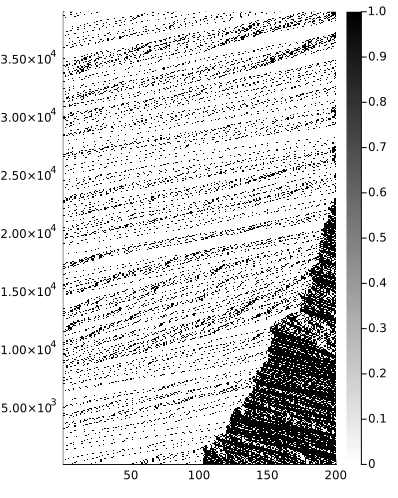

In [ ]:
heatmap(reshape(N, L, iter)',   c=cgrad([:white, :black]), clim=(0,1), size = (400, 500) )

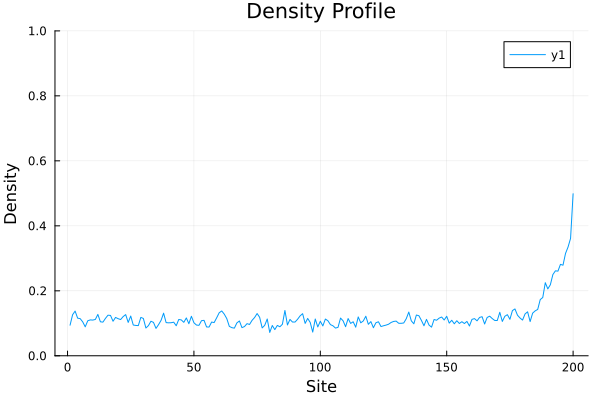

In [10]:
plot(1:200, mean(M[1][:, 25000:end], dims=2), yrange=(0,1), xlabel="Site", ylabel="Density", title="Density Profile")

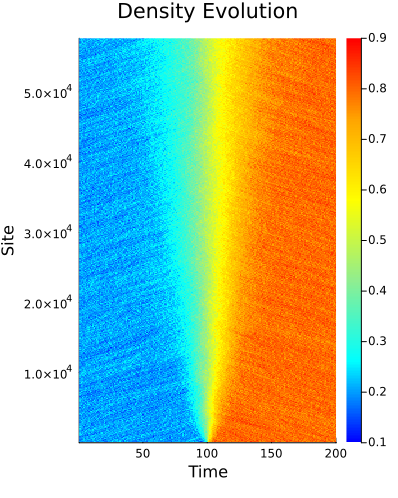

In [20]:
L = 200;
α = 0.2;
β = 0.2;
weights = [fill(α, L÷2); fill(1-β, L÷2)]
s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
s = [s1; s2]
ProgressMeter.ijulia_behavior(:clear)

t_list=[]
t=0.0;
races = 300
M = []

for j in 1:races
    s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
    s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
    s = [s1; s2]
    T = 2000
    stats = ContinuousTrajectory(L)
    t, s = trajectory(s, t, α, β, T; stats = stats)
    #println(t)
    show_state(s)
    N = hcat(stats.N...)
    t_list = stats.times
    iter = length(t_list)
    #println(iter)
    events = stats.Events
    push!(M, N)
end

p = [size(M[i])[2] for i in 1:races]
p = minimum(p)
D = zeros(Bool, L, p, races)
for i in 1:races
    D[:,:,i]=M[i][:, 1:p]
end
#D = reshape(D, L, p, races)
D = (sum(D, dims=3) ./ races)[:,:,1]

heatmap(D', c=cgrad([:blue, :cyan, :lightgreen, :yellow, :orange, :red]), clim=(0.1,0.9), xlabel="Time", ylabel="Site", title="Density Evolution", size=(400,500))


In [29]:
D

200×57646 Matrix{Float64}:
 0.186667  0.183333  0.19      0.19      …  0.203333  0.21      0.213333
 0.173333  0.173333  0.173333  0.176667     0.223333  0.22      0.216667
 0.19      0.176667  0.17      0.17         0.226667  0.23      0.236667
 0.183333  0.203333  0.206667  0.203333     0.196667  0.193333  0.186667
 0.213333  0.21      0.21      0.203333     0.176667  0.18      0.18
 0.19      0.19      0.186667  0.2       …  0.196667  0.193333  0.193333
 0.213333  0.21      0.213333  0.206667     0.226667  0.23      0.233333
 0.193333  0.193333  0.183333  0.19         0.206667  0.203333  0.206667
 0.213333  0.21      0.213333  0.213333     0.186667  0.186667  0.183333
 0.15      0.153333  0.16      0.153333     0.216667  0.213333  0.213333
 ⋮                                       ⋱                      ⋮
 0.806667  0.82      0.823333  0.82         0.746667  0.74      0.746667
 0.82      0.82      0.816667  0.823333     0.806667  0.803333  0.8
 0.84      0.84      0.836667  0.836667 

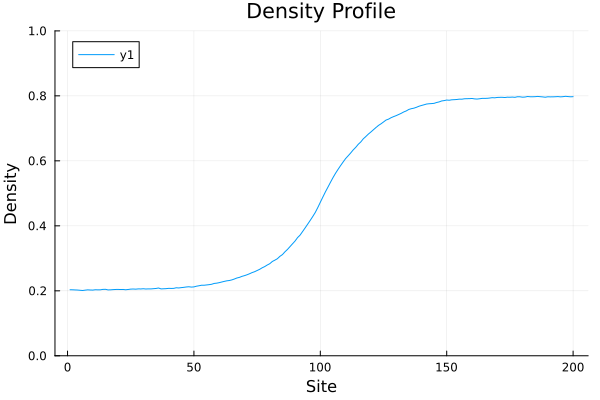

In [33]:
plot(1:200, mean(D, dims=2), yrange=(0,1), xlabel="Site", ylabel="Density", title="Density Profile")

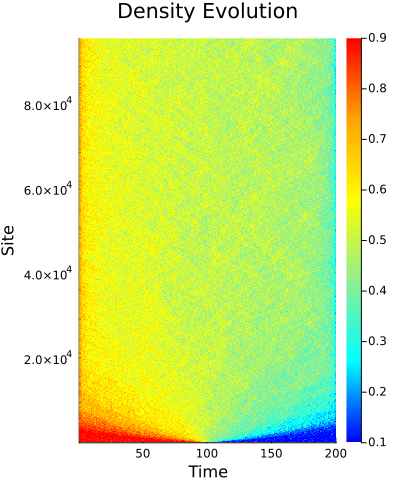

In [12]:
L = 200;
α = 0.9;
β = 0.9;
weights = [fill(α, L÷2); fill(1-β, L÷2)]
s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
s = [s1; s2]
ProgressMeter.ijulia_behavior(:clear)

t_list=[]
t=0.0;
races = 150
M = []

for j in 1:races
    s1 = BitVector(sample(0:1,Weights([1-α, α]), L÷2))
    s2 = BitVector(sample(0:1,Weights([β, 1-β]), L÷2))
    s = [s1; s2]
    T = 2000
    stats = ContinuousTrajectory(L)
    t, s = trajectory(s, t, α, β, T; stats = stats)
    #println(t)
    show_state(s)
    N = hcat(stats.N...)
    t_list = stats.times
    iter = length(t_list)
    #println(iter)
    events = stats.Events
    push!(M, N)
end

p = [size(M[i])[2] for i in 1:races]
p = minimum(p)
D = zeros(Bool, L, p, races)
for i in 1:races
    D[:,:,i]=M[i][:, 1:p]
end
#D = reshape(D, L, p, races)
D = (sum(D, dims=3) ./ races)[:,:,1]

heatmap(D', c=cgrad([:blue, :cyan, :lightgreen, :yellow, :orange, :red]), clim=(0.1,0.9), xlabel="Time", ylabel="Site", title="Density Evolution", size=(400,500))

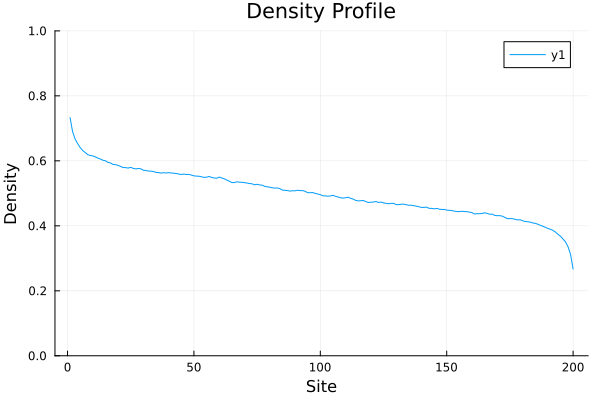

In [17]:
plot(1:200, mean(D, dims=2), yrange=(0,1), xlabel="Site", ylabel="Density", title="Density Profile")